# 5.3.1. 전이 학습 - 특성 추출 기법

## 라이브러리 설치, 호출

In [ ]:
# 라이브러리 설치
!pip install opencv-python

- OpenCV(Open Source Computer Vision Library): 오픈 소스 컴퓨터 비전 라이브러리
- OpenCV-Python: 파이썬에서도 사용 가능

In [ ]:
# 라이브러리 호출
import os
import time
import copy
import glob
import cv2  # 앞서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision  # 컴퓨터 비전 용도의 패키지
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용되는 패키지
import torchvision.models as models # 다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

import matplotlib.pyplot as plt

## 데이터 준비

### 이미지 전처리

In [ ]:
data_path = "/content/drive/MyDrive/Euron_DL/Week4/catanddog/train"  # 이미지 데이터가 위치한 경로 지정

transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
) # 1

train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform = transform
) # 2

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = 32,
    num_workers = 8,
    shuffle = True
) # 3

print(len(train_dataset))

385


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


**1. <torchvision.transform>**
- 이미지 데이터를 변환하여 모델(네트워크)의 입력으로 사용할 수 있게 변환해줌


```
transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)
```

- 파라미터
  - Resize: 이미지 크기를 조정. 합성곱층을 위해 이미지 크기를 조정하는 전처리 과정. 256x256 크기로 이미지 데이터를 조정.
  - RandomResizedCrop: 이미지를 랜덤한 크기 및 비율로 자름. 데이터 확장 용도. 이미지를 랜덤한 비율로 자른 후 데이터 크기를 조정.
  - RandomHorizontalFlip: 이미지를 랜덤하게 수평으로 뒤집음.
  - ToTensor: 이미지 데이터를 텐서로 변환
  


**2. <datasets.ImageFolder>**
- 데이터로더가 데이터를 불러올 대상/경로와 방법/전처리를 정의


```
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform = transform
)
```
- 파라미터
  - data_path: 불러올 데이터가 위치한 경로
  - transform: 이미지 데이터에 대한 전처리


**3. <data.DataLoader>**
- 데이터를 불러오는 부분
- 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당

```
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = 32,
    num_workers = 8,
    shuffle = True
)
```
- 파라미터
  - train_dataset: 데이터셋 지정
  - batch_size: 한 번에 불러올 데이터양을 결정하는 배치 크기를 설정
  - num_workers: 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정. 너무 많이 사용하면 오류가 발생하거나 메모리 부족 현상이 발생할 수 있음.
  - shuffle: 데이터를 무작위로 섞을지를 지정. True로 설정하면 데이터를 무작위로 섞어서 랜덤으로 불러옴.

### 학습에 사용될 이미지 출력

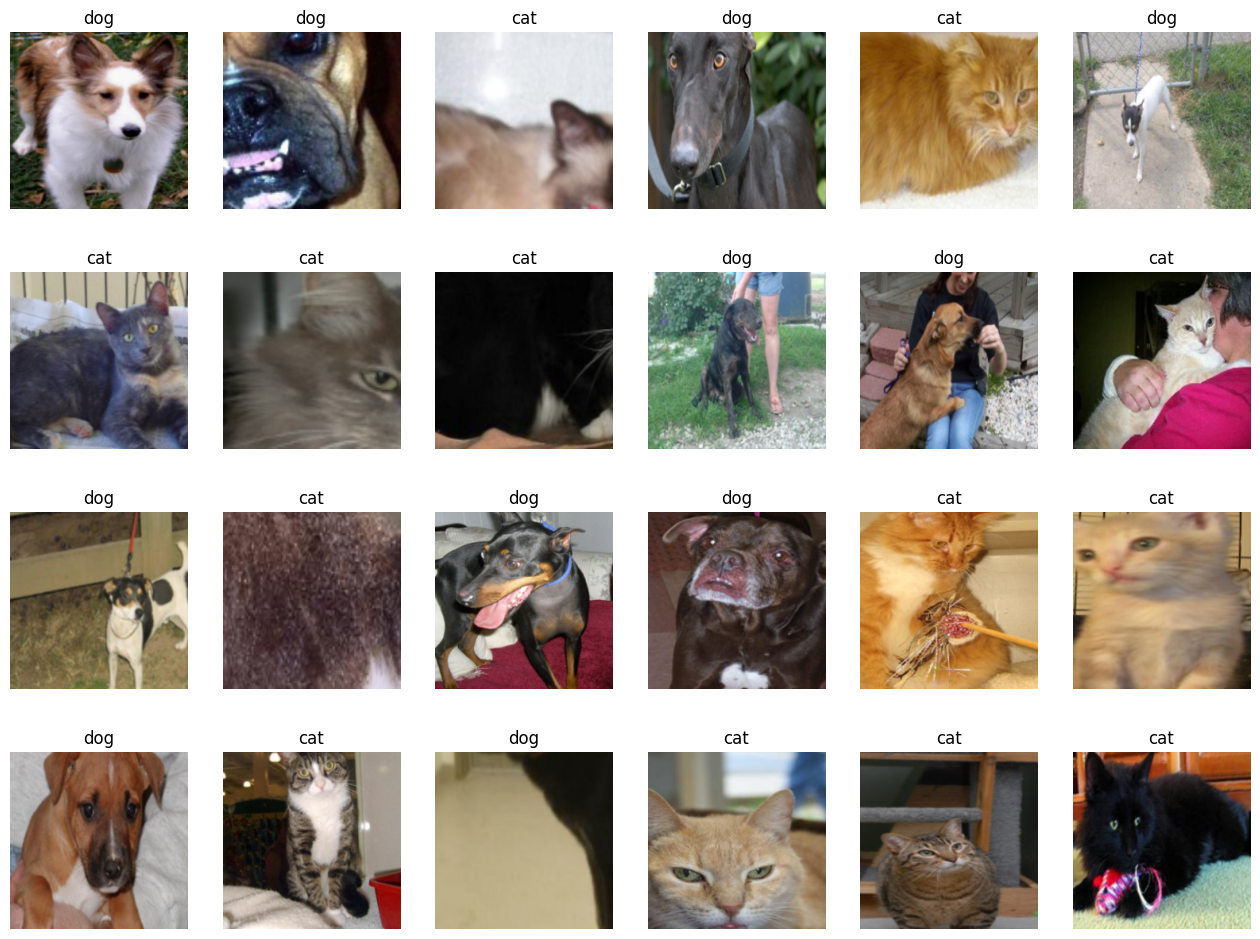

In [ ]:
samples, labels = next(iter(train_loader)) # 1
classes = {0: 'cat', 1:'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16, 24))
for i in range(24):
  a = fig.add_subplot(4, 6, i+1)
  a.set_title(classes[labels[i].item()])  # 레이블 정보(클래스)를 함께 출력
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0))) # 2

plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)


**1. <iter, next>**


- 반복자를 사용하려면 iter( ), next( )가 필요
- iter( ): 전달된 데이터의 반복자를 꺼내 반환
- next( ): 그 반복자가 다음에 출력해야 할 요소를반환
- iter( )로 반복자를 구하고 그 반복자를 next( )에 전달하여 차례대로 꺼낼 수 있음


```
samples, labels = next(iter(train_loader))
```
- 반복자: train_loader

  => train_loader에서 samples와 labels 값을 순차적으로 꺼내서 저장



**2. <np.transpose>**
- 행과 열을 바꿈으로써 행렬의 차원을 바꿈
- 행렬의 내적 연산을 위해 행렬의 차원을 변경

## 사전 훈련된 모델 다운로드

In [ ]:
resnet18 = models.resnet18(pretrained=True) # pretrained=True: 사전 학습된 가중치 사용

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**<ResNet 18>**
- 50개의 계층으로 구성된 합성곱 신경망
- ImageMet 데이터베이스의 100만개가 넘는 영상을 이용하여 훈련된 신경망
- 전이 학습에 사용되도록 사전 훈련된 모델을 제공
- 입력 제약이 매우 크고, 충분한 메모리(RAM)가 없으면 학습 속도가 느릴 수 있음

**<사전 훈련된 모델>**
- 무작위의 가중치로 모델 구성


```
import torchvision.model as models
resnet18 = models.resnet18()
alexnet = models.alexnet()
vgg16 = models.vgg16()
squeeznet = models.squeezenet1_0()
...
```
- 사전 학습된 모델(의 가중치 값) 사용

  : pretrained=True로 설정


```
import torchvision.model as models
resnet18 = models.resnet18(pretrained=True)
alexnet = models.alexnet(pretrained=True)
vgg16 = models.vgg16(pretrained=True)
squeeznet = models.squeezenet1_0(pretrained=True)
...
```




## 모델 생성

### 사전 훈련된 모델의 파라미터 학습 유무 지정
- ResNet18의 합성곱층을 사용하되 파라미터에 대해서는 학습하지 않도록 고정

In [ ]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False # 1

set_parameter_requires_grad(resnet18)

**&lt;requires_grad&gt;**


```
param.requires_grad = False
```
- 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타냄
- 모델의 일부(합성곱층, 풀링층)를 고정하고 나머지를 학습하고자 할 때 requires_grad=False로 설정


### 완전연결층 추가
- 추가된 완전연결층은 개와 고양이 클래스를 분류하는 용도로 사용
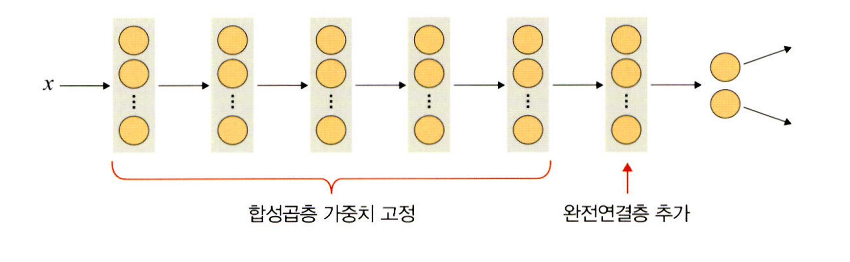

In [ ]:
resnet18.fc = nn.Linear(512, 2) # 2는 클래스가 두 개라는 의미

### 모델의 파라미터 값 확인

In [ ]:
for name, param in resnet18.named_parameters():
# model.named_parameters(): 모델에 접근하여 파라미터 값들을 가져올 때 사용
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0353, -0.0263, -0.0237,  ..., -0.0278, -0.0397,  0.0133],
        [-0.0141, -0.0262,  0.0053,  ...,  0.0084, -0.0232, -0.0373]])
fc.bias tensor([0.0100, 0.0005])


- 파라미터: weight, bias 사용

## 모델 객체 생성, 손실 함수 정의

In [ ]:
model = models.resnet18(pretrained=True)  # 모델의 객체 생성

for param in model.parameters():  # 모델의 합성곱층 가중치 고정
  param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): # 완전연결층은 학습
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()  # 손실함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 모델 학습

### 모델 학습을 위한 함수 생성

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time() # 컴퓨터의 현재 시각을 구하는 함수
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs): # 에포크(13)만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders:  # 데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad() # 기울기를 0으로 설정
      outputs = model(inputs) # 순전파 학습
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward() # 역전파 학습
      optimizer.step() # 가중치 업데이트

      running_loss += loss.item() * inputs.size(0)  # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장

    epoch_loss = running_loss / len(dataloaders.dataset)  # 평균 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset)  # 평균 정확도 계산

    print('Loss : {:.4f} Acc : {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)

    torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/Euron_DL/Week4/',
                                              '{0:0=2d}.pth'.format(epoch)))  # 모델 재사용을 위해 저장
    print()

  time_elapsed = time.time() - since  # 실행 시간(학습 시간)을 계산

  print('Training complete in {:.0f}m, {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history, loss_history  # 모델의 정확도와 오차를 반환

- ResNet18에 추가된 완전연결층은 학습을 하도록 설정
- 학습을 통해 얻어지는 파라미터를 옵티마이저에 전달해서 최종적으로 모델 학습에 사용

### 파라미터 학습 결과를 옵티마이저에 전달
- 완전연결층의 어떤 파라미터들이 옵티마이저로 전달되는지를 보여줌

In [ ]:
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param)  # 파라미터 학습 결과를 저장
    print('\t', name)

optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


- weight와 bias 값들이 업데이트되고 옵티마이저에 전달

### 모델 학습
- 모델 훈련을 위해 전달되는 파라미터: 모델, 학습 데이터, 손실 함수, 옵티마이저, 장치(CPU/GPU)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss() # 손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss : 0.3838 Acc : 0.8753

Epoch 1/12
----------
Loss : 0.3217 Acc : 0.8675

Epoch 2/12
----------
Loss : 0.2911 Acc : 0.8623

Epoch 3/12
----------
Loss : 0.2818 Acc : 0.8675

Epoch 4/12
----------
Loss : 0.3061 Acc : 0.8494

Epoch 5/12
----------
Loss : 0.2605 Acc : 0.8857

Epoch 6/12
----------
Loss : 0.1846 Acc : 0.9325

Epoch 7/12
----------
Loss : 0.2394 Acc : 0.8961

Epoch 8/12
----------
Loss : 0.1838 Acc : 0.9195

Epoch 9/12
----------
Loss : 0.2019 Acc : 0.9169

Epoch 10/12
----------
Loss : 0.1618 Acc : 0.9325

Epoch 11/12
----------
Loss : 0.1752 Acc : 0.9221

Epoch 12/12
----------
Loss : 0.2547 Acc : 0.8805

Training complete in 0m, 48s
Best Acc: 0.932468


## 테스트 데이터로 정확도 측정

### 테스트 데이터 호출 및 전처리

In [ ]:
test_path = "/content/drive/MyDrive/Euron_DL/Week4/catanddog/test"

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)

test_dataset = torchvision.datasets.ImageFolder(
    root = test_path,
    transform = transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


### 테스트 데이터 평가 함수 생성

In [ ]:
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('/content/drive/MyDrive/Euron_DL/Week4/' + '*.pth')  # 1
  saved_models.sort() # 불러온 .pth 파일들을 정렬
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path, weights_only=False)) # .pth 로드 에러 해결
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
        outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs.data, 1) # 2
      preds[preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
      preds[preds < 0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds.eq(labels).int().sum()  # 3

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)  # 테스트 데이터의 정확도 계산
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
    acc_history.append(epoch_acc.item())
    print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history  # 계산된 정확도 반환


**1. &lt;globe&gt;**
- 현재 디렉토리에서 원하는 파일들만 추출하여 가져올 때 사용

```
saved_models = glob.glob('/content/drive/MyDrive/Euron_DL/Week4/' + '*.pth')
```
- 설정한 경로에서 pth 확장자를 갖는 파일을 가져오라는 의미
- pth 확장자: 훈련 데이터로 모델을 훈련시킬 때 생성된 파일

**2. <torch.max>**
- 주어진 텐서 배열의 최댓값이 들어 있는 index를 반환하는 함수


```
_, preds = torch.max(outputs.data, 1)
```
예) y_pred = [[0.2, 0.7, 0.8, 0.4]]에 torch.max(y_pred.data, 1) 적용

=> 최댓값은 0.8, 그 인덱스는 0.2

=> 반환값: 2


**3. <preds.eq(labels)>**
- preds 배열과 labels가 일치하는지 검사하는 용도로 사용

```
running_corrects += preds.eq(labels.cpu()).int().sum()
```
- .sum( ): 모델의 예측 결과와 정답(레이블)이 일치하는 것들의 개수 합을 숫자로 출력


### 테스트 데이터를 평가 함수에 적용
- 모델 평가 함수에 테스트 데이터를 적용해서 실제로 성능(정확도)을 측정

In [ ]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/Euron_DL/Week4/00.pth', '/content/drive/MyDrive/Euron_DL/Week4/01.pth', '/content/drive/MyDrive/Euron_DL/Week4/02.pth', '/content/drive/MyDrive/Euron_DL/Week4/03.pth', '/content/drive/MyDrive/Euron_DL/Week4/04.pth', '/content/drive/MyDrive/Euron_DL/Week4/05.pth', '/content/drive/MyDrive/Euron_DL/Week4/06.pth', '/content/drive/MyDrive/Euron_DL/Week4/07.pth', '/content/drive/MyDrive/Euron_DL/Week4/08.pth', '/content/drive/MyDrive/Euron_DL/Week4/09.pth', '/content/drive/MyDrive/Euron_DL/Week4/10.pth', '/content/drive/MyDrive/Euron_DL/Week4/11.pth', '/content/drive/MyDrive/Euron_DL/Week4/12.pth']
Loading model /content/drive/MyDrive/Euron_DL/Week4/00.pth
Acc: 0.9592

Loading model /content/drive/MyDrive/Euron_DL/Week4/01.pth
Acc: 0.8980

Loading model /content/drive/MyDrive/Euron_DL/Week4/02.pth
Acc: 0.9082

Loading model /content/drive/MyDrive/Euron_DL/Week4/03.pth
Acc: 0.9490

Loading model /content/drive/MyDrive/Euron_DL/Week4/04.pth
Acc: 0.9388

Loa

## 모델 학습 결과 시각화

### 훈련과 테스트 데이터에 대한 정확도

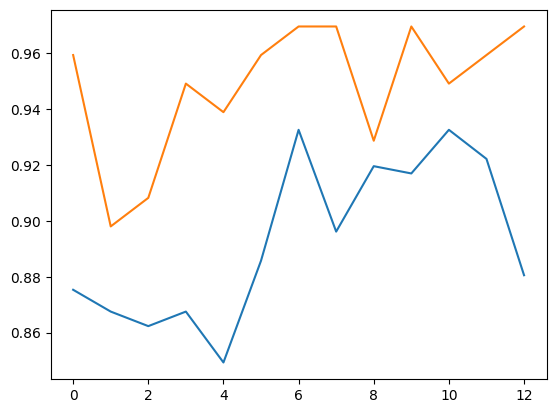

In [ ]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

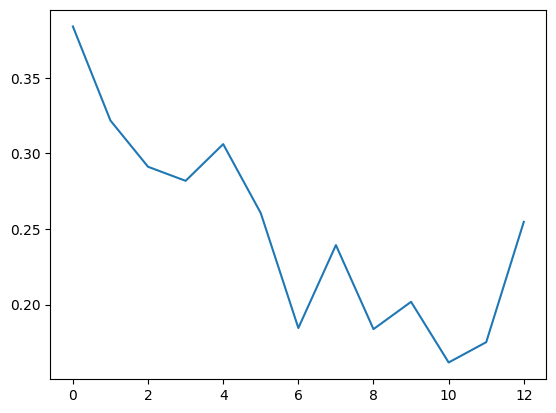

In [ ]:
plt.plot(train_loss_hist)
plt.show()

## 예측된 이미지 출력

### 예측 이미지 출력을 위한 전처리 함수

In [ ]:
def im_convert(tensor):
  image = tensor.clone().detach().numpy() # 1
  image = image.transpose(1, 2, 0)
  image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))
  image = image.clip(0, 1)  # 2
  return image

**1. <tensor.clone( ).detach( )>**


```
image = tensor.clone().detach().numpy()
```
- tensor.clone( ): 기존 텐서의 내용을 복사한 텐서를 생성하겠다는 의미
- detach( ): 기존 텐서에서 기울기가 전파되지 않는 텐서
- tensor.clone( ).detach( ): 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지는 않겠다는 의미


| 구분 | 메모리 | 계산 그래프 상주 유무 |
|----------|----------|----------|
| tensor.clone( ) | 새롭게 할당  | 계산 그래프에 계속 상주  |
| tensor.detach( )  | 공유해서 사용  | 계산 그래프에 상주하지 않음  |
| tensor.clone( ).detach( ) | 새롭게 할당 | 계산 그래프에 상주하지 않음|

**<계산 그래프>**
- 계산 과정을 그래프로 나타낸 것
- 그래프: 여러 개의 노드와 그 노드들을 연결하는 선인 엣지로 구성
- 계산 그래프를 사용하는 이유
  - 국소적 계산이 가능
  - 역전파를 통한 미분 계산이 편리. 연쇄 법칙을 이용하여 빠르고 간편하게 미분을 계산.

**<연쇄 법칙/체인 룰>**
- 합성함수(두 개 이상의 함수가 결합된 함수)의 미분법
- 예
  - z = (x + y)^2을 z = r^2, t = x + y의 합성함수로 표현
  - 각 합성함수의 미분 결과를 곱한 결과로 나타내는 것
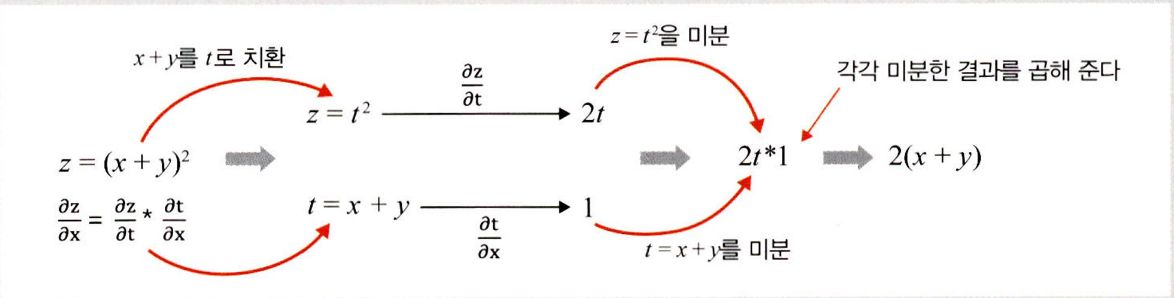


**2. <clip( )>**
- 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용

```
image = image.clip(0, 1)
```
- image 데이터를 0~1 값으로 제한


### 강아지/고양이 예측 결과 출력

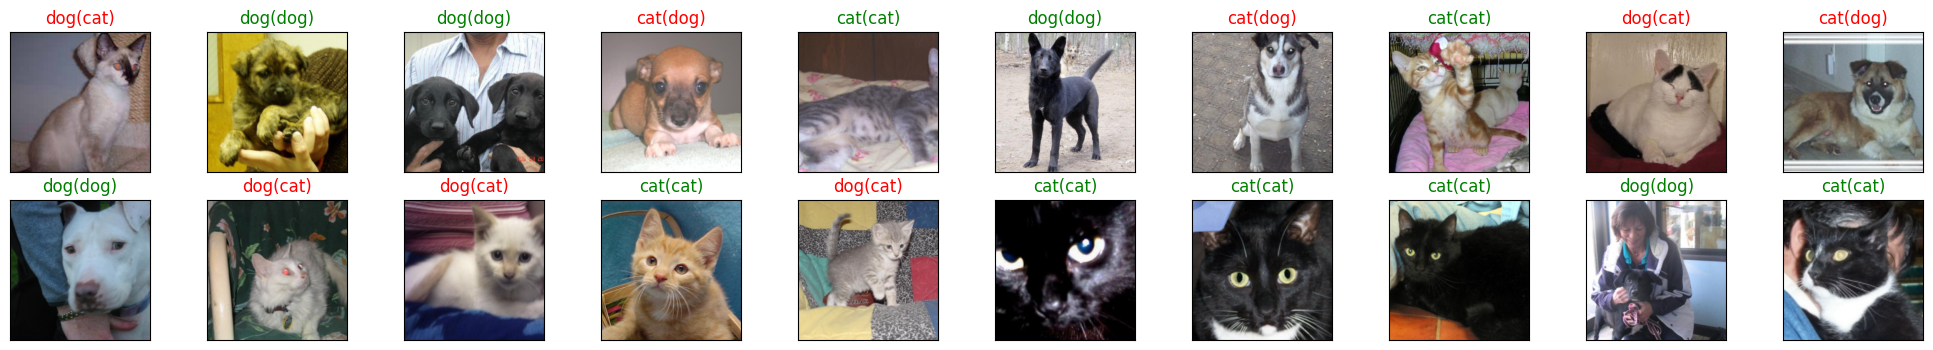

<Figure size 640x480 with 0 Axes>

In [ ]:
classes = {0:'cat', 1:'dog'}    # 강아지, 고양이 두 개에 대한 레이블

dataiter = iter(test_loader)  # 테스트 데이터셋을 로드
images, labels = next(dataiter)  # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옴
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])  # 1
  plt.imshow(im_convert(images[idx])) # 이미지 출력을 위해 위에서 정의한 im_convert 함수 적용
  a.set_title(classes[labels[i].item()])

  ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
              color=("green" if preds[idx]==labels[idx] else "red")) # 2

plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)  # 3

**1. &lt;add_subplot&gt;**
- 한 화면에 여러 개의 이미지를 담기 위해 사용


```
ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
```
- 파라미터
  - 첫번째 파라미터: 행의 수. 이미지를 두 줄로 출력
  - 두번째 파라미터: 열의 수. 한 줄에 열 개의 이미지를 출력
  - 세번째 파라미터: 인덱스를 의미. 행과 열을 기분으로 순차적으로 이미지 출력.
  - 네번째 파라미터: 틱(x축, y축 선)을 삭제하겠다는 의미.


**2. <classes[preds[idx].item( )]>**

- preds[idx].item( ) 값이 classes로 정의된 0과 1 중 어떤 값을 갖는지 판별하겠다는 의미
- 0이면 고양이, 1이면 강아지로 출력
```
ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
              color=("green" if preds[idx]==labels[idx] else "red"))
```




**3. &lt;subplot_adjust&gt;**
- figure 안에서 서브플롯의 위치를 조정할 때 사용
- left, bottom, right, top으로 이미지 위치 조정
- hspace, wspace를 이용해서 서브플롯 간의 간격(너비와 높이의 비율)을 조정
```
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
```

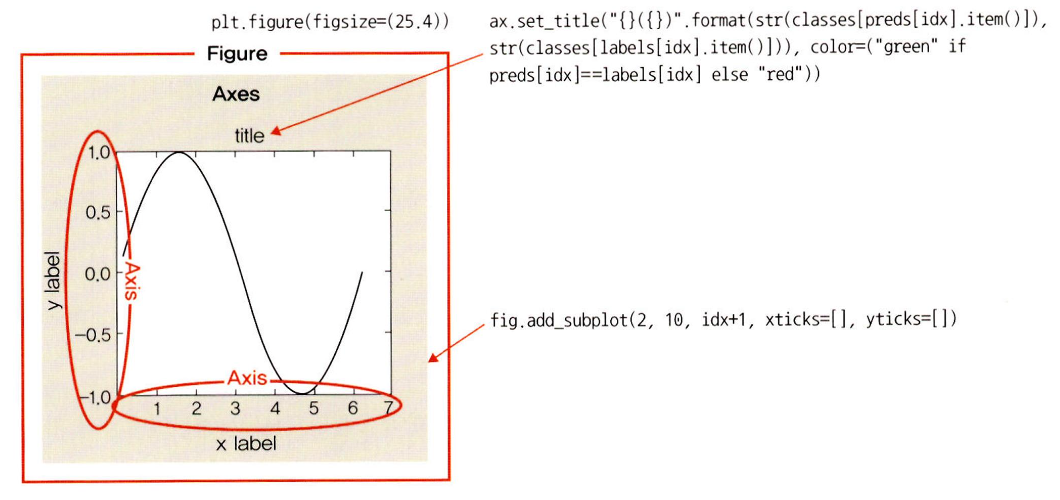

# 5.4.1. 설명 가능한 CNN - 특성맵 시각화

# 라이브러리 설치, 호출
- PIL(Pythin Image Library)
  - 다양한 이미지 파일 형식을 지원
  - 강력한 이미지 처리와 그래픽 기능을 제공하는 이미지 프로세싱 라이브러리

In [ ]:
!pip install pillow

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 네트워크 생성
- 설명 가능한 모델을 위해 13개의 합성곱층과 두 개의 완전연결층으로 구성된 네트워크 생성
- 합성곱층과 완전연결층은 렐루 활성화 함수 사용

In [ ]:
class XAI(torch.nn.Module):
  def __init__(self, num_classes=2):
    super(XAI, self).__init__() # nn.Module 초기화

    ## 합성곱층
    self.features = nn.Sequential(
        # 입력: [B(batch size), 3, 224, 224]
        nn.Conv2d(3, 64, kernel_size=3, bias=False),  # [B, 64, 222, 222]
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),  # inplace=True: 기존의 데이터를 연산의 결괏값으로 대체
        nn.Dropout(0.3),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),  # [B, 64, 222, 222]
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # [B, 64, 111, 111]

        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False), # [B, 128, 111, 111]
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),  # [B, 128, 111, 111]
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # [B, 128, 55, 55]

        nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),  # [B, 256, 55, 55]
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),  # [B, 256, 55, 55]
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),  # [B, 256, 55, 55]
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # [B, 256, 27, 27]

        nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),  # [B, 512, 27, 27]
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),  # [B, 512, 27, 27]
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),  # [B, 512, 27, 27]
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # [B, 256, 13, 13]

        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),  # [B, 512, 13, 13]
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),  # [B, 512, 13, 13]
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),  # [B, 512, 13, 13]
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # [B, 512, 6, 6]
    )

    ## 완전연결층
    self.classifier = nn.Sequential(
        nn.Linear(512, 512, bias=False),
        nn.Dropout(0.5),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes),  # 최종 출력 클래스 수
    )

  def forward(self, x):
    x = self.features(x)  # [B, 512, 6, 6]
    x = x.view(-1, 512)
    x = self.classifier(x)  # [B, num_classes]
    return F.log_softmax(x) # 1


**<로그 소프트맥스(log_softmax( ))>**
- 신경망 말단의 결괏값들을 확률 개념으로 해석하기 위해 소프트맥스 함수의 결과에 log 값을 취한 연산
- 소프트맥스가 아닌 로그 소프트맥스를 사용하는 이유: 소프트맥스는 기울기 소멸 문제에 취약하기 때문

## 모델 객체화
- 앞에서 생성된 모델을 model = XAI( )로 객체화
- 장치(CPU/GPU)에 할당

In [ ]:
model = XAI() # model이라는 이름의 객체를 생성
model.to(device)  # model을 장치에 할당
model.eval()  # 테스트 데이터에 대한 모델 평가 용도로 사용

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

## 특성 맵을 확인하기 위한 클래스 정의
- 특성 맵: 합성곱층을 입력 이미지와 필터를 연산하여 얻은 결과
- 합성곱층에서 입력과 출력을 알 수 있다면 특성 맵에 대한 값들을 확인할 수 있다는 의미
- 예) 앞 코드의 출력 결과인 (0): Conv2d(3, 64, kernel_size=(3, 3), stride(1, 1), bias=False)에 대한 특성 맵을 확인하기 위한 클래스를 정의

In [ ]:
class LayerActivations:
  features = []
  def __init__(self, model, layer_num):
    self.hook = model[layer_num].register_forward_hook(self.hook_fn)  # 1

  def hook_fn(self, module, input, output):
    self.features = output.detach().numpy()

  def remove(self): # hook 삭제
    self.hook.remove()

**<hook>**
- 파이토치는 매 계층마다 print문을 사용하지 않더라도 hook 기능을 사용하여 각 계층의 활성화 함수 및 기울기 값을 확인할 수 있음

```
self.hook = model[layer_num].register_forward_hook(self.hook_fn)
```
- register_forward_hook: 순전파 중에 각 네트워크 모듈의 입력 및 출력을 가져오는 것


- 특정한 값으로 정의되지 않은 중간 변수에 대한 기울기 값을 알 수 있음
- hook을 이용하면 중간 결괏값들을 확인할 수 있음


## 이미지 호출
- 특성 맵 정보를 가져올 이미지 호출

torch.Size([1, 3, 100, 100])


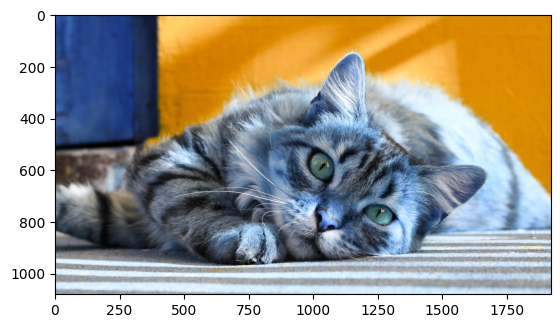

In [ ]:
img = cv2.imread("/content/drive/MyDrive/Euron_DL/Week4/cat.jpg")
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR) # 1
img = ToTensor()(img).unsqueeze(0)  # 2
print(img.shape)

**1. <cv2.resize>**
- 이미지 크기를 변경할 때 사용

```
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
```

- 파라미터
  - 첫번째 파라미터: 변경할 이미지 파일
  - 두번째 파라미터: 변경될 이미지 크기를 (너비, 높이)로 지정
  - interpolation: 보간법

**<보간법>**
- 이미지 크기를 변경할 경우 변형된 이미지의 픽셀을 추정해서 값을 할당
- 이미지 비율을 변경하면 존재하지 않는 영역에 새로운 픽셀 값을 매핑하거나 존재하는 픽셀들을 압축해서 새로운 값을 할당
- 보간법: 이런 상황을 피하기 위해 이미지상에 존재하는 픽셀 데이터(xi, yi)들에 대해 근사 함수 f(x, y)를 적용해서 새로운 픽셀 값을 구하는 것

=> 추정해야 하는 픽셀을 보간법을 이용해 값을 할당


**2. <unsqueeze( )>**


```
img = ToTensor()(img).unsqueeze(0)
```

- 1차원 데이터를 생성하는 함수
- 이미지 데이터를 텐서로 변환 -> 1차원으로 변경

## (0): Conv2d 특성 맵 확인
- (0): Conv2d(3, 64, kernel_size=(3, 3), stride(1, 1), bias=False)에 대한 특성 맵 확인

In [ ]:
result = LayerActivations(model.features, 0)  # 0번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

<ipython-input-5-74d9a2e233de>:80: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x) # 1, 다중 분류를 위한 log-softmax


### 특성 맵 시각화

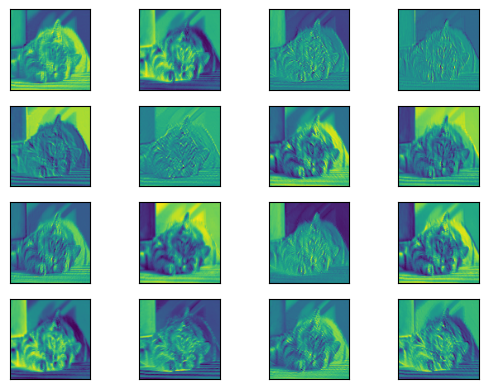

<Figure size 1200x800 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])

plt.show()

- 첫번째 Conv2d 계층에서 특성 맵에 대한 출력 결과

## 20번째 계층에 대한 특성 맵

In [ ]:
result = LayerActivations(model.features, 20) # 20번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

<ipython-input-5-74d9a2e233de>:80: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x) # 1, 다중 분류를 위한 log-softmax


### 특성맵 시각화

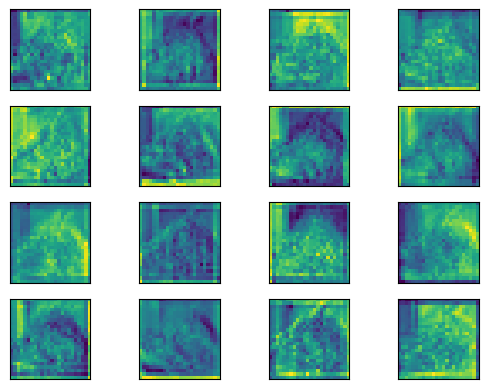

<Figure size 1200x800 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])

plt.show()

## 40번째 계층에 대한 특성 맵

In [ ]:
result = LayerActivations(model.features, 40) # 40번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

<ipython-input-5-74d9a2e233de>:80: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x) # 1, 다중 분류를 위한 log-softmax


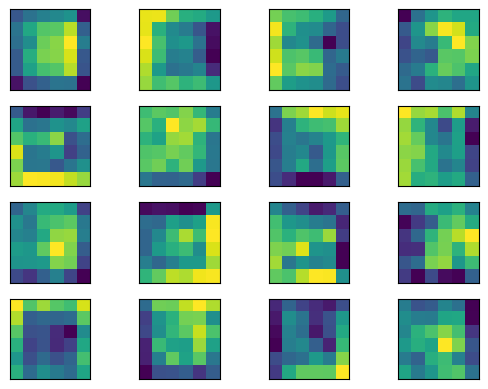

<Figure size 1200x800 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])

plt.show()

- 출력층에 가까울수록 원래 형태는 찾아볼 수 없고, 이미지 특징들만 전달됨